
Initial guess x0 = 2
Converged value = 1.000001
Iterations = 20

Initial guess x0 = 5
Converged value = 4.000000
Iterations = 6

Initial guess x0 = 3
Derivative zero at x = 3.0000. Method fails.
Converged value = 3.000000
Iterations = 0


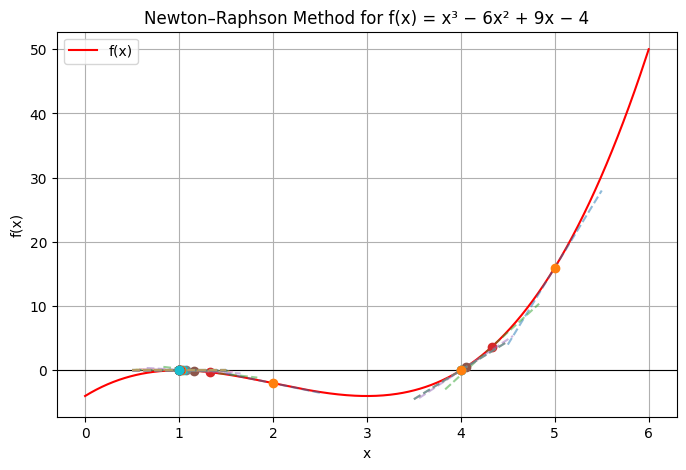

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# Define function and derivative
def f(x):
    return x**3 - 6*x**2 + 9*x - 4

def df(x):
    return 3*x**2 - 12*x + 9

# Newton–Raphson implementation
def newton_raphson(x0, tol=1e-6, max_iter=20):
    x = x0
    history = [x]

    for i in range(max_iter):
        if abs(df(x)) < 1e-6:
            print(f"Derivative zero at x = {x:.4f}. Method fails.")
            break

        dx = -f(x) / df(x)
        x = x + dx
        history.append(x)

        if abs(dx) < tol:
            break

    return x, history

# Run for different initial guesses

x0_list = [2, 5, 3]
results = {}

for x0 in x0_list:
    print(f"\nInitial guess x0 = {x0}")
    root, path = newton_raphson(x0)
    results[x0] = path
    print(f"Converged value = {root:.6f}")
    print(f"Iterations = {len(path)-1}")


# Plot f(x) and Newton paths
x_plot = np.linspace(0, 6, 400)
y_plot = f(x_plot)

plt.figure(figsize=(8, 5))
plt.axhline(0, color='black', linewidth=0.8)
plt.plot(x_plot, y_plot, label="f(x)", color="red")

# Plot iteration paths
for x0, path in results.items():
    for i in range(len(path)-1):
        xi = path[i]
        yi = f(xi)
        slope = df(xi)

        x_tan = np.linspace(xi - 0.5, xi + 0.5, 20)
        y_tan = yi + slope * (x_tan - xi)

        plt.plot(x_tan, y_tan, '--', alpha=0.5)
        plt.plot(xi, yi, 'o')

plt.xlabel("x")
plt.ylabel("f(x)")
plt.title("Newton–Raphson Method for f(x) = x³ − 6x² + 9x − 4")
plt.legend()
plt.grid(True)
plt.show()
